In [1]:
# Core Python
import os
import yaml

# CREDIT framework
from credit.datasets.era5_multistep_batcher import Predict_Dataset_Batcher
from credit.datasets.load_dataset_and_dataloader import BatchForecastLenDataLoader
from credit.parser import credit_main_parser
from credit.datasets import setup_data_loading
from credit.models import load_model
from credit.transforms import load_transforms, Normalize_ERA5_and_Forcing
from credit.datasets.era5_multistep_batcher import Predict_Dataset_Batcher
from credit.datasets.load_dataset_and_dataloader import BatchForecastLenDataLoader
from credit.transforms import Normalize_ERA5_and_Forcing
from tails.hurricane_genesis_ffs import HurricaneGenesisFFS
from tails.cyclone_phase_tracker import CyclonePhaseTracker

import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import xarray as xr
from typing import Tuple, Dict, Optional
from dataclasses import dataclass
from datetime import datetime, timedelta
import torch

from credit.output import make_xarray
from credit.interp import full_state_pressure_interpolation


# @dataclass
# class StormState:
#     """Storm state with MSLP + CPS."""
#     location: Tuple[float, float]
#     mslp: float
#     B: float
#     VTL: float
#     VTU: float
#     is_tropical: bool
#     phase: str

# class CyclonePhaseTracker:
#     """Compute CPS parameters from pressure interpolation.
#         https://moe.met.fsu.edu/cyclonephase/help.html
#     """
    
#     def __init__(self, latlons, radius_km=500):
#         self.lats = latlons.latitude.values
#         self.lons = np.where(
#             latlons.longitude.values > 180,
#             latlons.longitude.values - 360,
#             latlons.longitude.values
#         )
#         self.lons_2d, self.lats_2d = np.meshgrid(self.lons, self.lats, indexing='xy')
#         self.radius_km = radius_km
#         self.B_threshold = 10.0
    
#     def get_mask(self, center_lon, center_lat, hemisphere='right', motion_dir=45.0):
#         """Get semicircle mask for B parameter."""
#         R = 6371.0
#         lat1, lon1 = np.radians(center_lat), np.radians(center_lon)
#         lat2, lon2 = np.radians(self.lats_2d), np.radians(self.lons_2d)
        
#         dlat, dlon = lat2 - lat1, lon2 - lon1
#         a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
#         dist_km = 2 * R * np.arcsin(np.sqrt(a))
#         within = dist_km <= self.radius_km
        
#         y = np.sin(dlon) * np.cos(lat2)
#         x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
#         bearing = (np.degrees(np.arctan2(y, x)) + 360) % 360
#         relative = (bearing - motion_dir + 360) % 360
        
#         if hemisphere == 'right':
#             in_semi = (relative >= 270) | (relative <= 90)
#         else:
#             in_semi = (relative > 90) & (relative < 270)
        
#         return within & in_semi
    
#     def compute_CPS(self, pressure_interp, center_lon, center_lat, motion_dir=45.0):
#         """
#         Compute B, VTL, VTU from pressure_interp.
        
#         Parameters
#         ----------
#         pressure_interp : xarray.Dataset
#             Output from full_state_pressure_interpolation
#             Has Z_PRES(time, pressure, lat, lon)
#         center_lon, center_lat : float
#             Storm center
#         motion_dir : float
#             Direction of motion (degrees, 0=N, 90=E)
        
#         Returns
#         -------
#         dict with B, VTL, VTU, is_tropical, phase
#         """
#         # Extract Z at 300, 600, 900 hPa
#         z300 = pressure_interp['Z_PRES'].sel(pressure=300).isel(time=0).values
#         z600 = pressure_interp['Z_PRES'].sel(pressure=600).isel(time=0).values
#         z900 = pressure_interp['Z_PRES'].sel(pressure=900).isel(time=0).values
        
#         # B parameter (900-600 hPa thickness asymmetry)
#         thickness = z600 - z900
#         mask_r = self.get_mask(center_lon, center_lat, 'right', motion_dir)
#         mask_l = self.get_mask(center_lon, center_lat, 'left', motion_dir)
#         B = float(np.nanmean(thickness[mask_r]) - np.nanmean(thickness[mask_l]))
        
#         # VTL (lower thermal wind: 900-600 hPa)
#         R = 6371.0
#         lat_rad = np.radians(self.lats_2d - center_lat)
#         lon_rad = np.radians(self.lons_2d - center_lon)
#         a = np.sin(lat_rad/2)**2 + np.cos(np.radians(center_lat)) * np.cos(np.radians(self.lats_2d)) * np.sin(lon_rad/2)**2
#         dist = 2 * R * np.arcsin(np.sqrt(a))
#         mask = dist <= self.radius_km
        
#         thick_lower = z600 - z900
#         thick_lower[~mask] = np.nan
#         VTL = -(np.nanmax(thick_lower) - np.nanmin(thick_lower))
        
#         # VTU (upper thermal wind: 600-300 hPa)
#         thick_upper = z300 - z600
#         thick_upper[~mask] = np.nan
#         VTU = -(np.nanmax(thick_upper) - np.nanmin(thick_upper))
        
#         # Classify
#         is_symmetric = abs(B) < self.B_threshold
#         has_warm_core_lower = VTL < 0
#         has_warm_core_upper = VTU < 0
#         is_tropical = is_symmetric and has_warm_core_lower and has_warm_core_upper
        
#         # Phase name
#         if is_symmetric and has_warm_core_lower and has_warm_core_upper:
#             phase = "Tropical"
#         elif is_symmetric and has_warm_core_lower:
#             phase = "Subtropical"
#         elif not is_symmetric and not has_warm_core_lower:
#             phase = "Extratropical"
#         elif not is_symmetric and has_warm_core_lower:
#             phase = "Hybrid"
#         else:
#             phase = "Cold Core"
        
#         return {
#             'B': B,
#             'VTL': VTL,
#             'VTU': VTU,
#             'is_tropical': is_tropical,
#             'phase': phase
#         }


# class HurricaneGenesisFFS_CPS:
#     """
#     CPS-enhanced FFS - inherits from original, overrides extratropical checks.
    
#     Usage:
#         # In notebook, just change:
#         # ffs = HurricaneGenesisFFS(...)
#         # to:
#         ffs = HurricaneGenesisFFS_CPS(...)
#     """
    
#     def __init__(self, base_ffs_instance):
#         """
#         Initialize by wrapping an existing FFS instance.
        
#         Parameters
#         ----------
#         base_ffs_instance : HurricaneGenesisFFS
#             Your already-initialized FFS object
#         """
#         # Store reference to base instance
#         self._base = base_ffs_instance
        
#         # Initialize CPS tracker
#         self.cps_tracker = CyclonePhaseTracker(
#             self._base.latlons, 
#             radius_km=500
#         )
#         self.storm_track_history = {}
        
#         print("✓ CPS tracker initialized")
#         print("✓ Using physics-based extratropical detection")
    
#     def __getattr__(self, name):
#         """Delegate everything else to base instance."""
#         return getattr(self._base, name)
    
#     def _compute_pressure_interp(self, y_phys, batch):
#         """Compute pressure interpolation for CPS."""
#         datetime_str = datetime.fromtimestamp(
#             batch["datetime"][0].item()
#         ).strftime('%Y-%m-%d %H:%M:%S')
        
#         darray_upper, darray_single = make_xarray(
#             y_phys,
#             datetime_str,
#             self._base.latlons.latitude.values,
#             self._base.latlons.longitude.values,
#             self._base.config,
#         )
        
#         ds_merged = xr.merge([
#             darray_upper.to_dataset(dim="vars"),
#             darray_single.to_dataset(dim="vars")
#         ])
        
#         return full_state_pressure_interpolation(
#             ds_merged,
#             self._base.surface_geopotential,
#             **self._base.config["predict"]["interp_pressure"]
#         )
    
#     def _estimate_motion(self, storm_id):
#         """Estimate storm motion direction from track history."""
#         if storm_id not in self.storm_track_history:
#             return 45.0
        
#         hist = self.storm_track_history[storm_id]
#         if len(hist['lons']) < 2:
#             return 45.0
        
#         dlon = hist['lons'][-1] - hist['lons'][-2]
#         dlat = hist['lats'][-1] - hist['lats'][-2]
#         return (np.degrees(np.arctan2(dlon, dlat)) + 360) % 360
    
#     def _check_cps(self, pressure_interp, location, storm_id):
#         """
#         Check if storm is extratropical using CPS.
        
#         Returns
#         -------
#         is_ET : bool
#             True if extratropical
#         cps_params : dict
#             CPS parameters for logging
#         """
#         lat, lon = location
        
#         # Update track history
#         if storm_id not in self.storm_track_history:
#             self.storm_track_history[storm_id] = {'lons': [], 'lats': []}
        
#         self.storm_track_history[storm_id]['lons'].append(lon)
#         self.storm_track_history[storm_id]['lats'].append(lat)
        
#         # Estimate motion direction
#         motion_dir = self._estimate_motion(storm_id)
        
#         # Compute CPS
#         cps = self.cps_tracker.compute_CPS(pressure_interp, lon, lat, motion_dir)
        
#         return not cps['is_tropical'], cps
    
#     def rollout(self, loader, mode='flux', initial_state=None, start_interface=-1, parent_config=None):
#         """
#         Override rollout to add CPS-based extratropical filtering.
#         Replaces all lat/lon geographic rules with physics-based checks.
#         """
#         # Reset tracking for flux mode
#         if mode == 'flux':
#             self._base.tracked_storms = {}
#             self._base.next_storm_id = 0
#             self.storm_track_history = {}
        
#         previous_location = None
#         if parent_config and parent_config.feature_location:
#             previous_location = parent_config.feature_location
        
#         trajectory_mslp = []
#         crossings = []
#         current_interface = start_interface
#         status = 'ongoing'
#         saved_states = {}
        
#         with torch.no_grad():
#             for batch in loader:
#                 step = batch["forecast_step"].item()
                
#                 if step == 1:
#                     if initial_state is not None:
#                         x = initial_state.to(self._base.device).float()
#                     else:
#                         if "x_surf" in batch:
#                             from credit.data import concat_and_reshape
#                             x = concat_and_reshape(batch["x"], batch["x_surf"]).to(self._base.device).float()
#                         else:
#                             from credit.data import reshape_only
#                             x = reshape_only(batch["x"]).to(self._base.device).float()
                
#                 if "x_forcing_static" in batch:
#                     x_forcing = batch["x_forcing_static"].to(self._base.device).permute(0, 2, 1, 3, 4).float()
#                     x = torch.cat((x, x_forcing), dim=1)
                
#                 y_pred = self._base.model(x, forecast_step=step - 1)
#                 y_phys = self._base.state_transformer.inverse_transform(y_pred.cpu())
                
#                 # Compute pressure interpolation (needed for both MSLP and CPS)
#                 pressure_interp = self._compute_pressure_interp(y_phys, batch)
                
#                 # Extract MSLP and append
#                 mslp_tensor = torch.from_numpy(
#                     pressure_interp['mean_sea_level_pressure'].values
#                 ).unsqueeze(1).unsqueeze(2)
#                 y_with_mslp = torch.cat([y_phys, mslp_tensor], dim=1)
                
#                 mslp, feat_idx, location = self._base.extract_mslp(
#                     y_with_mslp, batch, step, previous_location, mode
#                 )
                
#                 trajectory_mslp.append(mslp)
                
#                 # ========== CPS EXTRATROPICAL CHECK (SHOOT MODE) ==========
#                 if mode == 'shoot' and location is not None:
#                     try:
#                         is_ET, cps = self._check_cps(pressure_interp, location, storm_id=0)
                        
#                         if is_ET:
#                             lat, lon = location
#                             print(f"  → EXTRATROPICAL: {cps['phase']}")
#                             print(f"     B={cps['B']:.1f}m, VTL={cps['VTL']:.1f}m, VTU={cps['VTU']:.1f}m")
#                             print(f"     Location: ({lat:.1f}°N, {abs(lon):.1f}°W), MSLP={mslp:.1f} hPa")
                            
#                             # LOG EXTRATROPICAL STOP
#                             self._base.logger.log_early_stop(
#                                 reason='extratropical',
#                                 step=step,
#                                 mslp=mslp,
#                                 interface_idx=current_interface,
#                                 location=location,
#                                 cps_params=cps,
#                                 mode=mode,
#                                 parent_config=parent_config.config_name if parent_config else None
#                             )
                            
#                             status = 'extratropical'
#                             break
                    
#                     except Exception as e:
#                         print(f"  ⚠ CPS check failed: {e}")
                    
#                     previous_location = location
                
#                 # Save state
#                 y_norm = self._base.state_transformer.transform_array(y_phys).to(self._base.device)
                
#                 if batch.get("y_diag") is not None:
#                     varnum_diag = batch["y_diag"].shape[1]
#                     saved_states[step] = y_norm[:, :-varnum_diag, ...].cpu().clone()
#                 else:
#                     saved_states[step] = y_norm.cpu().clone()
                
#                 traj_status, interface_idx = self._base.check_trajectory_status(mslp, current_interface, mode)
                
#                 # ========== CPS EXTRATROPICAL CHECK (FLUX MODE) ==========
#                 if mode == 'flux':
#                     lambda_0 = self._base.interfaces[0]
                    
#                     for storm_id in list(self._base.tracked_storms.keys()):
#                         storm = self._base.tracked_storms[storm_id]
                        
#                         if not storm['saved'] and storm['mslp'] < lambda_0:
#                             storm_lat, storm_lon = storm['location']
                            
#                             try:
#                                 # Check CPS instead of lat/lon rules
#                                 is_ET, cps = self._check_cps(
#                                     pressure_interp, 
#                                     storm['location'], 
#                                     storm_id
#                                 )
                                
#                                 if is_ET:
#                                     print(f"  → Storm {storm_id} {cps['phase']}: B={cps['B']:.1f}m, not saved")
                                    
#                                     # LOG FLUX MODE EXTRATROPICAL REJECTION
#                                     self._base.logger.log_early_stop(
#                                         reason='extratropical_flux',
#                                         step=step,
#                                         mslp=storm['mslp'],
#                                         interface_idx=0,
#                                         location=storm['location'],
#                                         cps_params=cps,
#                                         mode='flux'
#                                     )
                                    
#                                     storm['saved'] = True
#                                     continue
                            
#                             except Exception as e:
#                                 print(f"  ⚠ CPS check failed for storm {storm_id}: {e}")
                            
#                             # Valid tropical genesis - save it
#                             crossing = self._base._create_crossing(
#                                 saved_states[step], step, storm['mslp'], 0,
#                                 batch, None, storm['location'], None, y_with_mslp
#                             )
#                             crossings.append(crossing)
#                             storm['saved'] = True
#                             print(f"  → Storm {storm_id} crossed λ₀: {storm['mslp']:.1f} hPa")
                            
#                             if self._base.visualize_mslp:
#                                 datetime_str = None
#                                 if batch and "datetime" in batch:
#                                     dt = datetime.fromtimestamp(batch["datetime"][0].item())
#                                     datetime_str = dt.strftime('%Y-%m-%d %H:%M UTC')
                                
#                                 mslp_channel_idx = 71
#                                 mslp_pa = y_with_mslp[0, mslp_channel_idx, 0].cpu().numpy()
#                                 mslp_hpa = mslp_pa / 100.0
                                
#                                 self._base._plot_mslp(
#                                     mslp_hpa, 
#                                     self._base.get_basin_mask(),
#                                     datetime_str,
#                                     storm_lat, storm_lon, storm['mslp'],
#                                     show_marker=True,
#                                     marker_label=f'λ₀ CROSSING (Storm {storm_id})'
#                                 )
#                                 import matplotlib.pyplot as plt
#                                 plt.pause(1.0)
                        
#                         # Remove dissipated storms
#                         if storm['mslp'] > self._base.state_A_threshold:
#                             print(f"  → Storm {storm_id} dissipated: {storm['mslp']:.1f} hPa")
#                             del self._base.tracked_storms[storm_id]
                
#                 # ========== TRAJECTORY STATUS HANDLING WITH LOGGING ==========
#                 if traj_status == 'crossed_forward':
#                     if mode == 'shoot':
#                         next_idx = current_interface + 1
#                         crossing = self._base._create_crossing(
#                             saved_states[step], step, mslp, next_idx,
#                             batch, feat_idx, location, 
#                             parent_config.config_name if parent_config else None,
#                             y_with_mslp
#                         )
#                         crossings.append(crossing)
#                         status = 'success'
                        
#                         if self._base.visualize_mslp and location:
#                             datetime_str = None
#                             if batch and "datetime" in batch:
#                                 dt = datetime.fromtimestamp(batch["datetime"][0].item())
#                                 datetime_str = dt.strftime('%Y-%m-%d %H:%M UTC')
                            
#                             mslp_channel_idx = 71
#                             mslp_pa = y_with_mslp[0, mslp_channel_idx, 0].cpu().numpy()
#                             mslp_hpa = mslp_pa / 100.0
                            
#                             self._base._plot_mslp(
#                                 mslp_hpa, 
#                                 self._base.get_basin_mask(),
#                                 datetime_str,
#                                 location[0], location[1], mslp,
#                                 show_marker=True,
#                                 marker_label=f'λ{next_idx} CROSSING'
#                             )
#                             import matplotlib.pyplot as plt
#                             plt.pause(1.5)
                        
#                         break
                    
#                     if mode == 'flux':
#                         current_interface = interface_idx
                
#                 elif traj_status == 'reached_B':
#                     crossing = self._base._create_crossing(
#                         saved_states[step], step, mslp, -1,
#                         batch, feat_idx, location,
#                         parent_config.config_name if parent_config else None,
#                         y_with_mslp
#                     )
#                     crossings.append(crossing)
#                     status = 'reached_B'
                    
#                     # LOG REACHED STATE B
#                     self._base.logger.log_early_stop(
#                         reason='reached_B',
#                         step=step,
#                         mslp=mslp,
#                         interface_idx=-1,
#                         location=location,
#                         mode=mode,
#                         parent_config=parent_config.config_name if parent_config else None
#                     )
                    
#                     if self._base.visualize_mslp and location:
#                         datetime_str = None
#                         if batch and "datetime" in batch:
#                             dt = datetime.fromtimestamp(batch["datetime"][0].item())
#                             datetime_str = dt.strftime('%Y-%m-%d %H:%M UTC')
                        
#                         mslp_channel_idx = 71
#                         mslp_pa = y_with_mslp[0, mslp_channel_idx, 0].cpu().numpy()
#                         mslp_hpa = mslp_pa / 100.0
                        
#                         self._base._plot_mslp(
#                             mslp_hpa, 
#                             self._base.get_basin_mask(),
#                             datetime_str,
#                             location[0], location[1], mslp,
#                             show_marker=True,
#                             marker_label='STATE B REACHED!'
#                         )
#                         import matplotlib.pyplot as plt
#                         plt.pause(2.0)
                    
#                     break
                
#                 elif traj_status == 'returned_A':
#                     # LOG RETURNED TO STATE A
#                     self._base.logger.log_early_stop(
#                         reason='returned_A',
#                         step=step,
#                         mslp=mslp,
#                         interface_idx=current_interface,
#                         location=location,
#                         mode=mode,
#                         parent_config=parent_config.config_name if parent_config else None
#                     )
                    
#                     status = 'failure'
#                     break
                
#                 elif traj_status == 'returned_backward':
#                     # LOG BACKWARD CROSSING
#                     self._base.logger.log_early_stop(
#                         reason='returned_backward',
#                         step=step,
#                         mslp=mslp,
#                         interface_idx=interface_idx if interface_idx is not None else -1,
#                         location=location,
#                         mode=mode,
#                         parent_config=parent_config.config_name if parent_config else None
#                     )
                    
#                     current_interface = interface_idx if interface_idx is not None else -1
                
#                 if batch.get("y_diag") is not None:
#                     varnum_diag = batch["y_diag"].shape[1]
#                     x = y_norm[:, :-varnum_diag, ...].detach()
#                 else:
#                     x = y_norm.detach()
                
#                 if batch.get("stop_forecast", torch.tensor(False)).item():
#                     if status == 'ongoing':
#                         final_status = 'completed' if mode == 'flux' else 'failure'
                        
#                         # LOG FORECAST COMPLETION
#                         self._base.logger.log_early_stop(
#                             reason=final_status,
#                             step=step,
#                             mslp=mslp,
#                             interface_idx=current_interface,
#                             location=location,
#                             mode=mode,
#                             parent_config=parent_config.config_name if parent_config else None
#                         )
                        
#                         status = final_status
#                     break
        
#         # Save crossings
#         for crossing in crossings:
#             self._base._save_crossing(crossing, mode)
        
#         # LOG TRAJECTORY STATISTICS
#         if len(trajectory_mslp) > 0:
#             self._base.logger.log_trajectory_stats(
#                 mode=mode,
#                 duration_steps=len(trajectory_mslp),
#                 max_mslp=max(trajectory_mslp),
#                 min_mslp=min(trajectory_mslp),
#                 interface_crossings=len(crossings)
#             )
        
#         return {
#             'status': status,
#             'mslp_trajectory': trajectory_mslp,
#             'crossings': crossings,
#             'final_mslp': trajectory_mslp[-1] if trajectory_mslp else None
#         }

In [3]:
filepath = "/glade/derecho/scratch/schreck/CREDIT_runs/ensemble/scheduler/" # "/glade/campaign/cisl/aiml/credit/models/one_degree_wxformer_6hr_ensemble/"
device = "cuda"

with open(os.path.join(filepath, "model.yml"), "r") as f:
    conf = yaml.safe_load(f)

conf = credit_main_parser(conf, parse_training=False, parse_predict=True, print_summary=False)
data_config = setup_data_loading(conf)

ensemble_size = 1
conf["trainer"]["ensemble_size"] = ensemble_size
conf["predict"]["ensemble_size"] = ensemble_size

In [4]:
model = load_model(conf, load_weights=True).to(device)
model = model.eval()

In [5]:
# start = "2022-09-17 00:00:00"
# end   = "2022-09-27 00:00:00"

start = "2022-08-21 00:00:00"
end   = "2022-09-10 00:00:00"

forecast_times = [[start, end]]


dataset_params = dict(
    varname_upper_air=data_config["varname_upper_air"],
    varname_surface=data_config["varname_surface"],
    varname_dyn_forcing=data_config["varname_dyn_forcing"],
    varname_forcing=data_config["varname_forcing"],
    varname_static=data_config["varname_static"],
    varname_diagnostic=data_config["varname_diagnostic"],
    filenames=data_config["all_ERA_files"],
    filename_surface=data_config["surface_files"],
    filename_dyn_forcing=data_config["dyn_forcing_files"],
    filename_forcing=data_config["forcing_files"],
    filename_static=data_config["static_files"],
    filename_diagnostic=data_config["diagnostic_files"],
    lead_time_periods=6,
    history_len=data_config["history_len"],
    skip_periods=data_config["skip_periods"],
    transform=load_transforms(conf),
    sst_forcing=data_config["sst_forcing"],
    batch_size=1,
    rank=0,
    world_size=1,
)

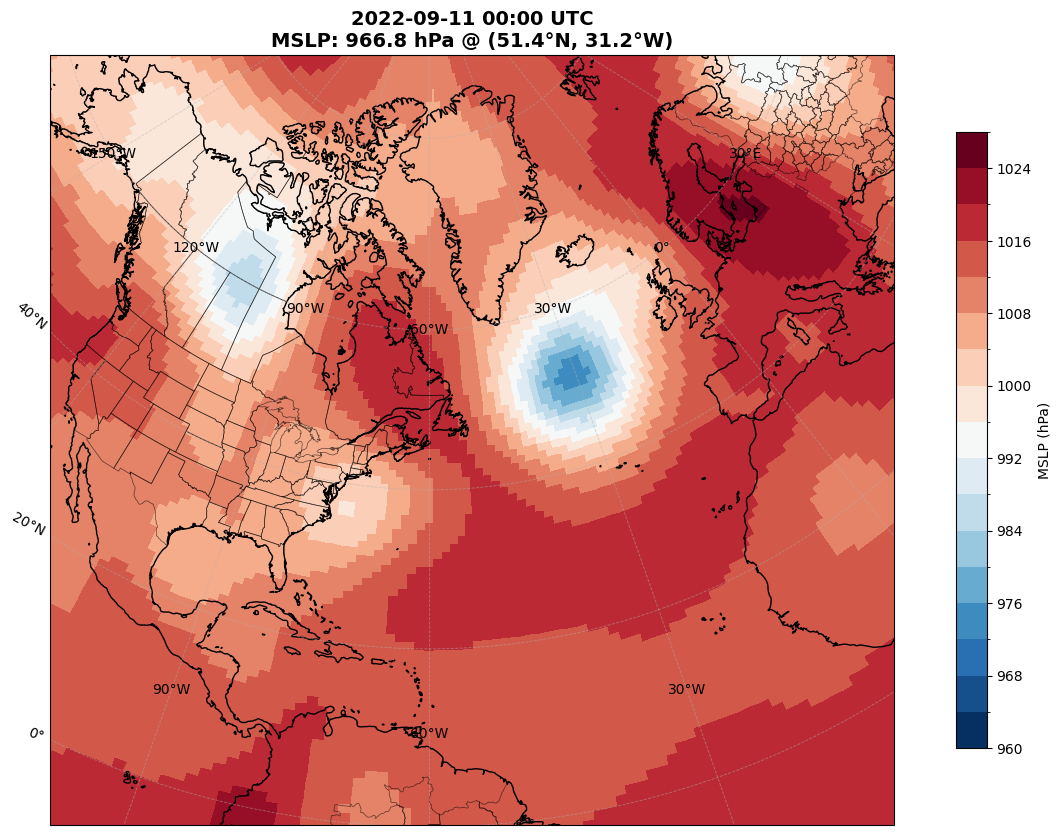

  → FAILURE: Extratropical (51.4°N > 50°N)
failure

⚠ EARLY STOP: 200 attempts with 0 successes
Interface λ_3→λ_4 appears unreachable


AttributeError: 'FFSLogger' object has no attribute 'log_early_stop'

In [6]:
initial_dataset = Predict_Dataset_Batcher(
    **dataset_params,
    fcst_datetime=forecast_times,
)

initial_loader = BatchForecastLenDataLoader(initial_dataset)

# Initialize FFS with tracking
ffs_base = HurricaneGenesisFFS(
    model=model,
    state_transformer=Normalize_ERA5_and_Forcing(conf),
    config=conf,
    initial_dataset=initial_dataset,
    dataset_params=dataset_params,
    interfaces=[1000, 988, 980, 975, 970],
    state_A=1008,
    state_B=965,
    max_attempts_without_success=200,
    output_dir="./ffs_cps",
    rank=0,
    world_size=1,
    worker_id=0,
)

ffs = HurricaneGenesisFFS_CPS(ffs_base)

# Enable visualization
ffs.enable_visualization()

# Run FFS (will show live MSLP plots and filter out preexisting storms)
ffs.run_ffs(initial_loader, n_flux_trials=20, n_shoot_trials=10)

# Disable when done
ffs.disable_visualization()